In [34]:
import joblib as joblib
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix, cohen_kappa_score

In [41]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_25_lowess_trainingset_1.csv')
df = pd.read_csv(x)
df = df[::1792].reset_index(drop=True)

df.loc[df['condition'] != 'CTR', 'condition'] = 'ALZ'

id = df.loc[:, 'id']
X = df.drop(columns=['id', 'condition'])
y = df.loc[:, 'condition']

df

,condition,id,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,ALZ,ACP_10,-48.860295,353,1.296317,1599,0.040254,1.0,0.0,1.0,0.0,0.0
1,ALZ,ACP_10,-105.081967,371,19.319672,540,0.736104,1.0,0.0,0.0,1.0,0.0
2,ALZ,ACP_10,-88.206557,289,-30.307377,1717,0.040546,1.0,0.0,0.0,0.0,1.0
3,ALZ,ACP_10,-101.153130,323,-12.241901,1749,0.062350,0.0,1.0,1.0,0.0,0.0
4,ALZ,ACP_10,-56.489071,291,-3.270492,1202,0.058418,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
511,ALZ,DFT_9,-43.666150,294,1.500517,1593,0.034770,1.0,0.0,0.0,1.0,0.0
512,ALZ,DFT_9,-40.538852,286,24.500000,1745,0.044578,1.0,0.0,0.0,0.0,1.0
513,ALZ,DFT_9,-46.445648,266,11.271780,1710,0.039971,0.0,1.0,1.0,0.0,0.0
514,ALZ,DFT_9,-35.163877,275,11.508568,1631,0.034419,0.0,1.0,0.0,1.0,0.0


### Dummy model

In [42]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_test)
proba = dummy_clf.predict_proba(X)
score = dummy_clf.score(X, y)

print(classification_report(y_test, y_pred))
print(balanced_accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

         ALZ       0.83      1.00      0.91        90
         CTR       0.00      0.00      0.00        18

    accuracy                           0.83       108
   macro avg       0.42      0.50      0.45       108
weighted avg       0.69      0.83      0.76       108

0.5


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

### Reference model

In [43]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ALZ       0.84      0.99      0.91        90
         CTR       0.50      0.06      0.10        18

    accuracy                           0.83       108
   macro avg       0.67      0.52      0.50       108
weighted avg       0.78      0.83      0.77       108



/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Binary classification

In [67]:
model = joblib.load('models/logistic_regression.pkl')

In [68]:
numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
# numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=200, subsample=200, output_distribution="normal", copy=True, random_state=42))])

categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

# pipeline = ImbPipeline([
#     ("preprocessor", preprocessor),
#     ("smote", SMOTE(random_state=42)), 
#     ('clf', clone(model['best_model']['clf']))
# ])

pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ('clf', clone(model['best_model']['clf']))
])


results = {
    'accuracy': [],
    'proba': [],
    'f1_score': [],
    'balanced_accuracy': [],
    'classification_report': [],
    'train_cond_distribution': [],
    'best_model': [],
    'test_cond_distribution': [],
    'confusion_matrices': [],
    'train_idx_folds': [],
    'X_train_folds': [],
    'y_train_folds': [],
    'cohen_kappa': []
}

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    lr = pipeline.fit(X_train, y_train)

    y_pred = lr.predict(X_test)
    score = lr.score(X_test, y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    y_pred = lr.predict(X_test)
    results['accuracy'].append(score)
    results['f1_score'].append(f1_macro)
    results['balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred, adjusted=True))
    results['classification_report'].append(classification_report(y_test, y_pred))
    results['train_idx_folds'].append(train_idx)
    results['X_train_folds'].append(X_train)
    results['y_train_folds'].append(y_train)
    results['best_model'].append(lr)
    results['cohen_kappa'].append(cohen_kappa_score(y_pred, y_test))

    results['train_cond_distribution'].append(y_train.value_counts()/6)
    results['test_cond_distribution'].append(y_test.value_counts()/6)

    cm = confusion_matrix(y_test, y_pred)
    results['confusion_matrices'].append(cm)

In [69]:
print(results['classification_report'][0])
print(results['balanced_accuracy'])

              precision    recall  f1-score   support

         ALZ       0.84      0.99      0.91        90
         CTR       0.50      0.06      0.10        18

    accuracy                           0.83       108
   macro avg       0.67      0.52      0.50       108
weighted avg       0.78      0.83      0.77       108

[0.04444444444444451]


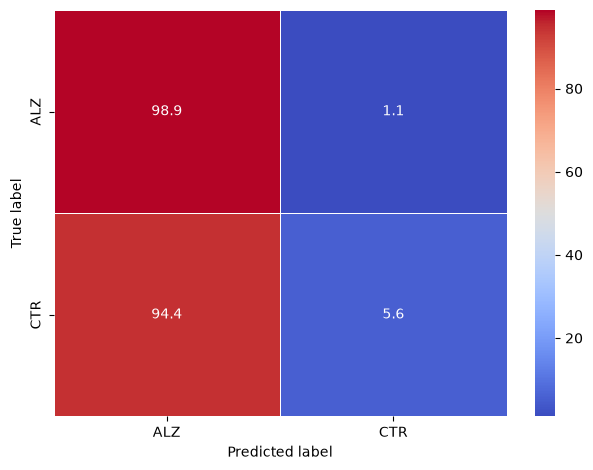

In [70]:
labels = ['ALZ', 'CTR']

lr_cm = pd.DataFrame(results['confusion_matrices'][0], index = labels, columns=labels)

lr_cm_pct = lr_cm.div(lr_cm.sum(axis=1), axis=0) * 100

sns.heatmap(lr_cm_pct, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()

In [3]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, classification_report, cohen_kappa_score


## Scaling
numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
# numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=200, subsample=200, output_distribution="normal", copy=True, random_state=42))])

categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

# pipeline = ImbPipeline([
#     ("preprocessor", preprocessor),
#     ("smote", SMOTE(random_state=42)), 
#     ('clf', SVC(random_state=42))
# ])

pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ('clf', SVC(random_state=42))
])

param_grid = [
    {
        'clf' : [SVC(random_state=42)],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
        'clf__kernel': ['linear', 'rbf', 'poly'],
        'clf__degree': [2, 3, 4]

    },
    {
        'clf' : [RandomForestClassifier(random_state=42)],
        'clf__n_estimators': [1, 10, 50, 100],
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': [5, 20, 50, 100],
        'clf__min_samples_split': [2, 5, 8, 10]
    },
    {
        'clf' : [LogisticRegression(random_state=42)],
        'clf__C': [0.01, 0.1, 0.5, 1.0, 1.5, np.inf],
        'clf__l1_ratio': [0, 0.5, 1],
        'clf__solver': ['lbfgs', 'newton-cholesky', 'sag', 'saga'],
        'clf__max_iter': [50, 200, 500, 1000]
    },
    {
        'clf' : [GradientBoostingClassifier(random_state=42)],
        'clf__loss': ['log_loss'],
        'clf__learning_rate': [0.01, 0.1, 1],
        'clf__n_estimators': [1, 100, 1000],
        'clf__min_samples_split': [2, 4, 6],
        'clf__max_depth': [1, 3, 5]
    },
    {
        'clf' : [KNeighborsClassifier()],
        'clf__n_neighbors': [1, 2, 3, 5],
        'clf__weights': ['uniform', 'distance'],
        'clf__algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'clf__p': [1, 2]
    },
    {
        'clf' : [AdaBoostClassifier(random_state=42)],
        'clf__n_estimators': [20, 50, 100],
        'clf__learning_rate': [0.01, 0.1, 1]
    }
]

## Store variables
results = {
    'accuracy': [],
    'proba': [],
    'f1_score': [],
    'balanced_accuracy': [],
    'cohen_kappa': [],
    'classification_report': [],
    'best_params': [],
    'best_model': [],
    'train_cond_distribution': [],
    'test_cond_distribution': [],
    'confusion_matrices': [],
    'train_idx_folds': [],
    'X_train_folds': [],
    'y_train_folds': []
}

## Optimise model using GridSearchCV
outer_cv = StratifiedGroupKFold(n_splits=5)
inner_cv = StratifiedGroupKFold(n_splits=5)

for train_idx, test_idx in outer_cv.split(X, y, groups=id):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    id_train, id_test = id.iloc[train_idx], id.iloc[test_idx]

    gridsearch = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=inner_cv, n_jobs=-1)
    gridsearch.fit(X_train, y_train, groups=id_train)

    best_params = gridsearch.best_params_
    best_model = gridsearch.best_estimator_

    y_pred = best_model.predict(X_test)
    # proba = best_model.predict_proba(X_test)

    score = best_model.score(X_test, y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results['accuracy'].append(score)
    # results['proba'].append(proba)
    results['f1_score'].append(f1_macro)
    results['balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred, adjusted=True))
    results['cohen_kappa'].append(cohen_kappa_score(y_pred, y_test))
    results['classification_report'].append(classification_report(y_test, y_pred))

    results['best_params'].append(best_params)
    results['best_model'].append(best_model)
    results['train_idx_folds'].append(train_idx)
    results['X_train_folds'].append(X_train)
    results['y_train_folds'].append(y_train)

    results['train_cond_distribution'].append(y_train.value_counts()/6)
    results['test_cond_distribution'].append(y_test.value_counts()/6)

    cm = confusion_matrix(y_test, y_pred)
    results['confusion_matrices'].append(cm)


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

In [4]:
print(results['balanced_accuracy'])
print(results['cohen_kappa'])
results['best_params']

[0.059523809523809534, 0.10897435897435903, 0.11217948717948723, 0.04166666666666652, 0.054487179487179516]
[0.06134969325153372, 0.09523809523809523, 0.11725293132328307, 0.03596127247579528, 0.06060606060606055]


[{'clf': KNeighborsClassifier(),
  'clf__algorithm': 'ball_tree',
  'clf__n_neighbors': 1,
  'clf__p': 2,
  'clf__weights': 'uniform'},
 {'clf': KNeighborsClassifier(),
  'clf__algorithm': 'ball_tree',
  'clf__n_neighbors': 1,
  'clf__p': 2,
  'clf__weights': 'uniform'},
 {'clf': KNeighborsClassifier(),
  'clf__algorithm': 'ball_tree',
  'clf__n_neighbors': 1,
  'clf__p': 2,
  'clf__weights': 'uniform'},
 {'clf': RandomForestClassifier(random_state=42),
  'clf__criterion': 'entropy',
  'clf__max_depth': 20,
  'clf__min_samples_split': 10,
  'clf__n_estimators': 1},
 {'clf': RandomForestClassifier(random_state=42),
  'clf__criterion': 'entropy',
  'clf__max_depth': 20,
  'clf__min_samples_split': 8,
  'clf__n_estimators': 1}]

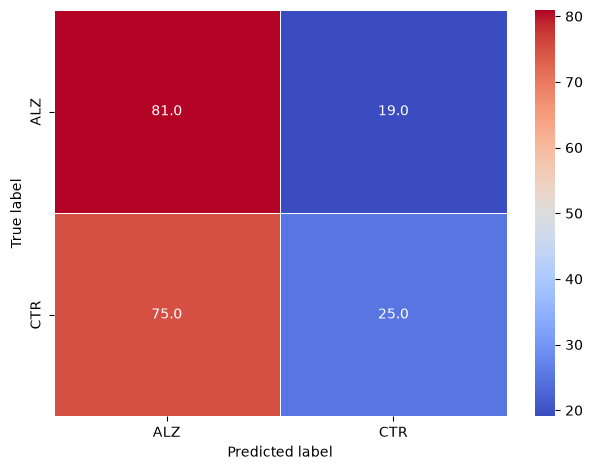

In [7]:
labels = ['ALZ', 'CTR']

lr_cm = pd.DataFrame(results['confusion_matrices'][0], index = labels, columns=labels)

lr_cm_pct = lr_cm.div(lr_cm.sum(axis=1), axis=0) * 100

sns.heatmap(lr_cm_pct, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()

In [72]:
model = joblib.load('results/lr_bi_EF_RS.pkl')
model.keys()

dict_keys(['accuracy', 'proba', 'f1_score', 'balanced_accuracy', 'classification_report', 'train_cond_distribution', 'best_model', 'test_cond_distribution', 'confusion_matrices', 'train_idx_folds', 'X_train_folds', 'y_train_folds'])

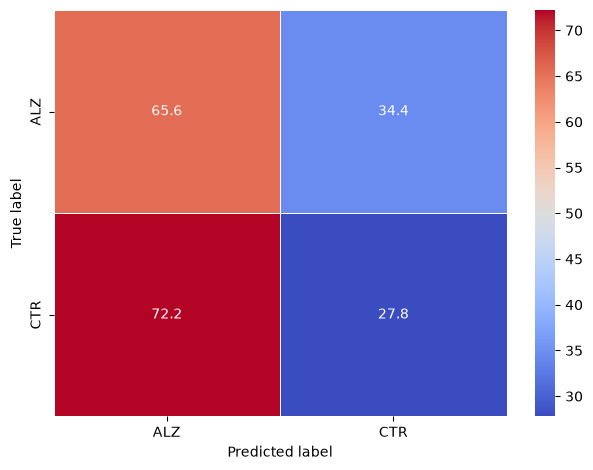

In [63]:
labels = ['ALZ', 'CTR']

lr_cm = pd.DataFrame(model['confusion_matrices'][0], index = labels, columns=labels)

lr_cm_pct = lr_cm.div(lr_cm.sum(axis=1), axis=0) * 100

sns.heatmap(lr_cm_pct, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()

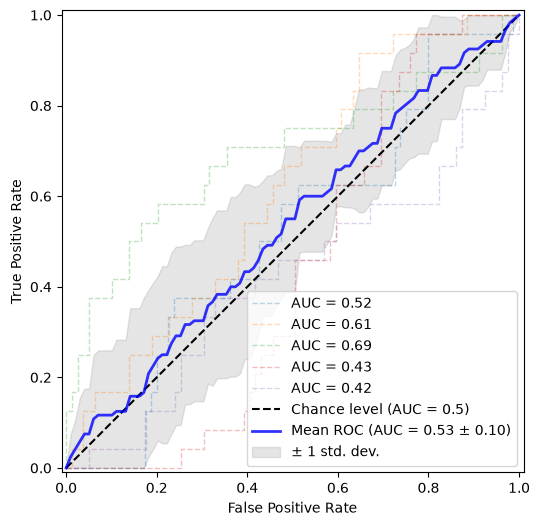

In [73]:
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.model_selection import StratifiedKFold, cross_validate

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits)
classifier = LogisticRegression(C=np.inf, l1_ratio=0, max_iter=500, random_state=42).fit(X, y)
cv_results = cross_validate(
    model['best_model'][0], X, y, cv=cv, return_estimator=True, return_indices=True
)

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]
curve_kwargs_list = [
    dict(alpha=0.3, lw=1, color=colors[fold % len(colors)]) for fold in range(n_splits)
]

mean_fpr = np.linspace(0, 1, 100)
interp_tprs = []

_, ax = plt.subplots(figsize=(6, 6))
viz = RocCurveDisplay.from_cv_results(
    cv_results,
    X,
    y,
    ax=ax,
    curve_kwargs=curve_kwargs_list,
    plot_chance_level=True,
)

for idx in range(n_splits):
    interp_tpr = np.interp(mean_fpr, viz.fpr[idx], viz.tpr[idx])
    interp_tpr[0] = 0.0
    interp_tprs.append(interp_tpr)

mean_tpr = np.mean(interp_tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(viz.roc_auc)

ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(interp_tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate"
)
ax.legend(loc="lower right")
plt.savefig('figures/analysis/ROC_bi_lr.png', dpi=450)
plt.show()